https://www.kaggle.com/datasets/mrdaniilak/russia-real-estate-20182021.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/AI/all_v2.csv", parse_dates=['date'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.805808,30.376141,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,12:04:54,55.683807,37.297405,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,15:44:00,56.295250,44.061637,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,11:24:52,44.996132,39.074783,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,17:42:43,55.918767,37.984642,81,3,13,14,2,60.0,10.0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 13 columns):
 #   Column         Dtype         
---  ------         -----         
 0   price          int64         
 1   date           datetime64[ns]
 2   time           object        
 3   geo_lat        float64       
 4   geo_lon        float64       
 5   region         int64         
 6   building_type  int64         
 7   level          int64         
 8   levels         int64         
 9   rooms          int64         
 10  area           float64       
 11  kitchen_area   float64       
 12  object_type    int64         
dtypes: datetime64[ns](1), float64(4), int64(7), object(1)
memory usage: 543.2+ MB


In [ ]:
df.describe()

,price,date,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
count,5.477006e+06,5477006,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06,5.477006e+06
mean,4.422029e+06,2019-11-20 16:33:10.095173120,5.403826e+01,5.324433e+01,4.307141e+03,1.948966e+00,6.214530e+00,1.139892e+01,1.726173e+00,5.391825e+01,1.062840e+01,3.945399e+00
min,-2.144967e+09,2018-02-19 00:00:00,4.145906e+01,1.989020e+01,3.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-2.000000e+00,7.000000e-02,1.000000e-02,1.000000e+00
25%,1.950000e+06,2019-03-14 00:00:00,5.337768e+01,3.777790e+01,2.661000e+03,1.000000e+00,2.000000e+00,5.000000e+00,1.000000e+00,3.800000e+01,7.000000e+00,1.000000e+00
50%,2.990000e+06,2019-10-13 00:00:00,5.517139e+01,4.306774e+01,2.922000e+03,2.000000e+00,5.000000e+00,1.000000e+01,2.000000e+00,4.802000e+01,9.700000e+00,1.000000e+00
75%,4.802000e+06,2020-07-18 00:00:00,5.622613e+01,6.564895e+01,6.171000e+03,3.000000e+00,9.000000e+00,1.600000e+01,2.000000e+00,6.313000e+01,1.270000e+01,1.100000e+01
max,2.147484e+09,2021-05-01 00:00:00,7.198040e+01,1.625361e+02,6.188800e+04,5.000000e+00,3.900000e+01,3.900000e+01,1.000000e+01,7.856000e+03,9.999000e+03,1.100000e+01
std,2.150752e+07,NaN,4.622758e+00,2.074763e+01,3.308050e+03,1.038537e+00,4.957419e+00,6.535734e+00,1.082133e+00,3.335293e+01,9.792380e+00,4.558357e+00


Фильтрация данных

Фильтр по координатам Перми

In [ ]:
df_n = df[
    (df["geo_lat"] >= 57.95) & (df["geo_lat"] <= 58.10) &
    (df["geo_lon"] >= 56.15) & (df["geo_lon"] <= 56.35)
]
print(f"После фильтра по Перми: {len(df_n)} записей")

После фильтра по Перми: 25913 записей


Фильтр по 2021 году

In [ ]:
from datetime import datetime
date_start = datetime(2021, 1, 1)
date_end = datetime(2021, 12, 31)
df_n = df_n[(df_n["date"] >= date_start) & (df_n["date"] <= date_end)]
print(f"После фильтра по 2021 году: {len(df_n)} записей")

После фильтра по 2021 году: 2617 записей


Подготовка данных

Удаляем пропуски

In [ ]:
df_n = df_n.dropna()

Преобразуем студии

In [ ]:
df_n['rooms'] = df_n['rooms'].replace(-1, 0)

Удаляем выбросы

In [ ]:
q_low = df_n['price'].quantile(0.01)
q_high = df_n['price'].quantile(0.99)
df_n = df_n[(df_n['price'] >= q_low) & (df_n['price'] <= q_high)]

In [ ]:
feature_cols = ['area', 'rooms', 'level', 'levels', 'kitchen_area', 'building_type', 'object_type']
X = df_n[feature_cols].copy()
y = df_n['price'].copy()

print(f"\nПризнаки для модели: {feature_cols}")


Признаки для модели: ['area', 'rooms', 'level', 'levels', 'kitchen_area', 'building_type', 'object_type']


диаграммы рассеяния

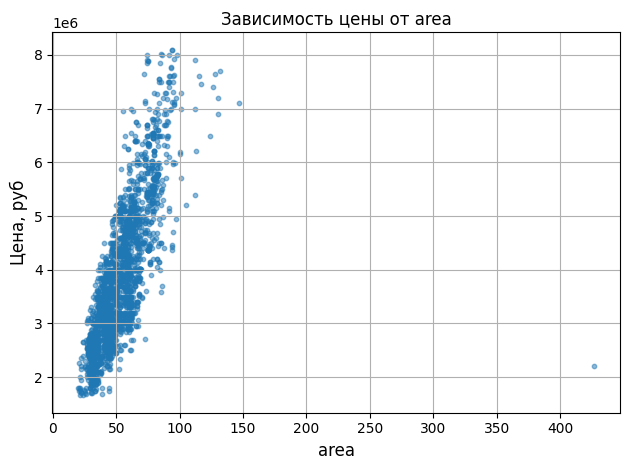

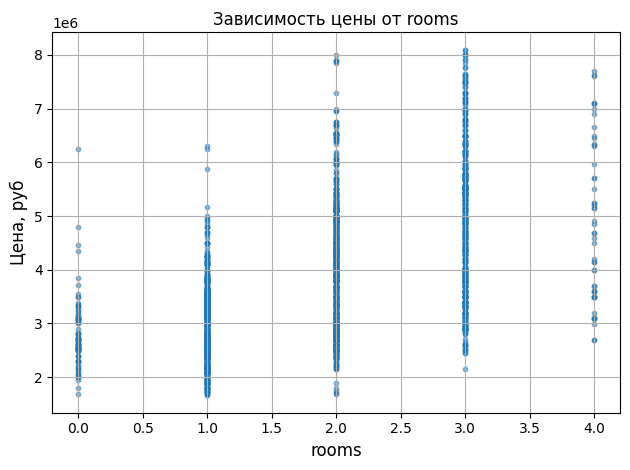

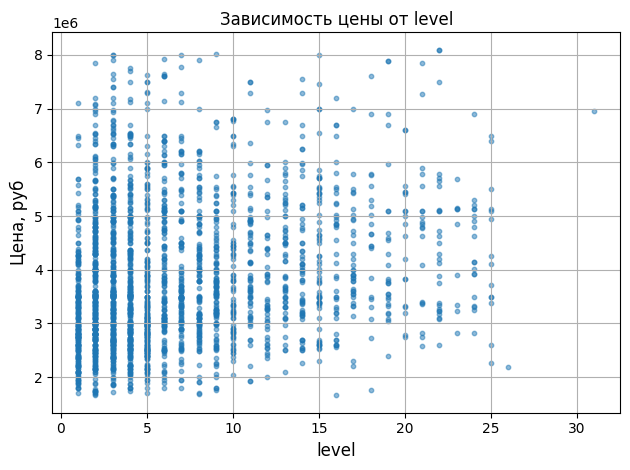

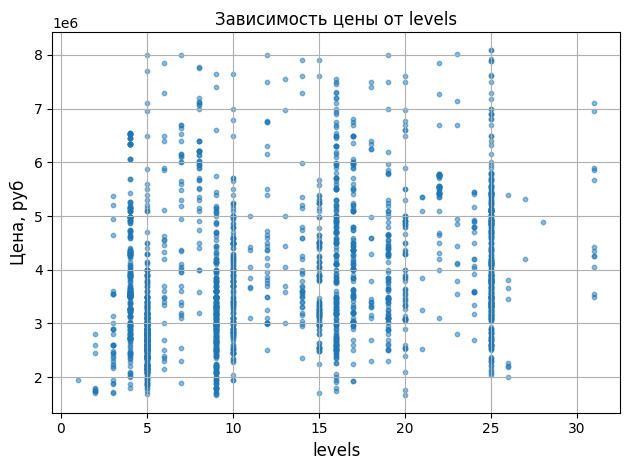

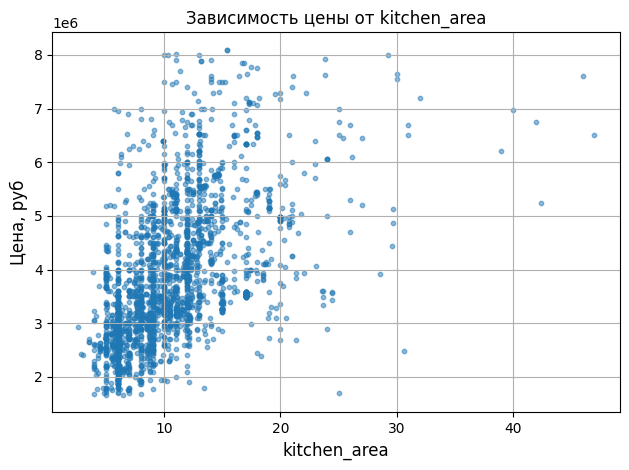

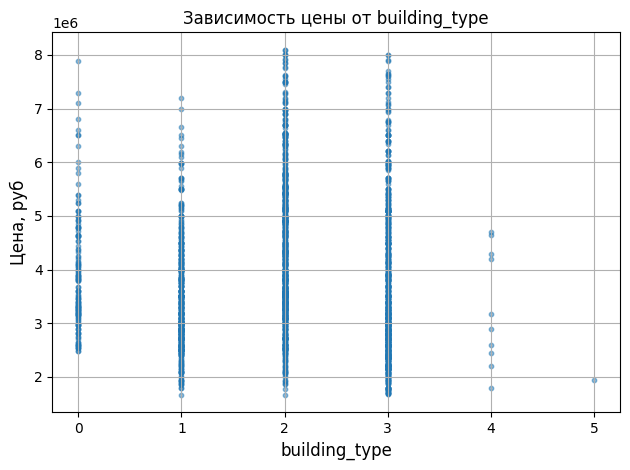

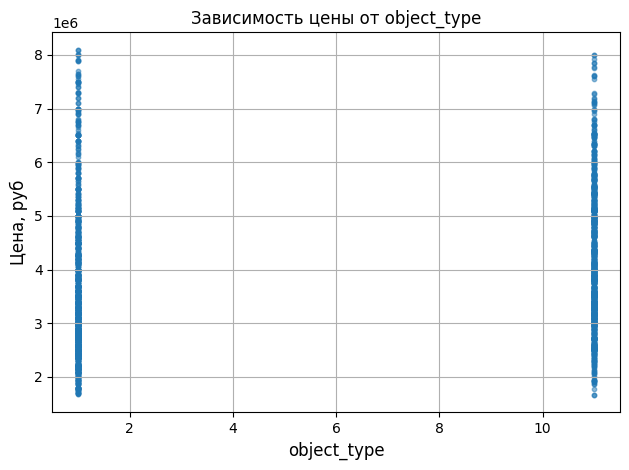

In [ ]:
for idx, feature_name in enumerate(feature_cols):
    plt.scatter(X[feature_name], y, alpha=0.5, s=10)
    plt.ylabel('Цена, руб', size=12)
    plt.xlabel(feature_name, size=12)
    plt.title(f'Зависимость цены от {feature_name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Разделение на выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

Функция для оценки моделей

In [ ]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, y_pred):
    cv_scores = cross_val_score(estimator=model, X=X_train, y=y_train, cv=10, scoring='r2')

    r2 = r2_score(y_test, y_pred)
    n = X_test.shape[0]
    p = X_test.shape[1]
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = np.mean(np.abs(y_test - y_pred))

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Adj_R2': adjusted_r2, 'CV_R2': cv_scores.mean()}

Обучение моделей

In [ ]:
results = {}

Линейная регрессия

In [ ]:
modelLR = LinearRegression()
modelLR.fit(X_train, y_train)
y_pr_LR = modelLR.predict(X_test)

In [ ]:
results['Linear Regression'] = evaluate_model(modelLR, "Linear Regression", X_train, y_train, X_test, y_test, y_pr_LR)

Text(0.5, 0, 'Площадь, кв.м')

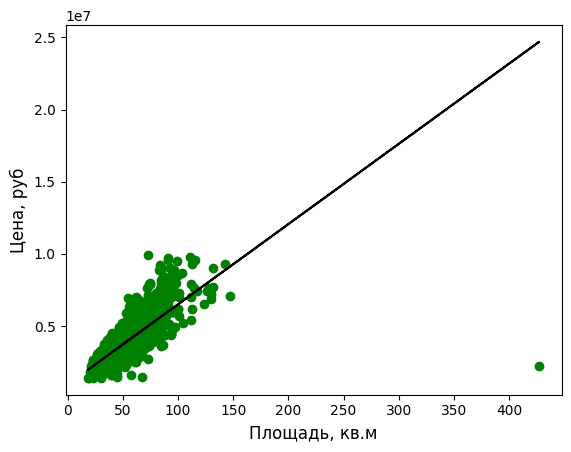

In [ ]:
X2 = X[feature_cols[0]].values[:, np.newaxis]
y2 = y.values
model2 = LinearRegression()
model2.fit(X2, y2)
plt.scatter(X2, y2, color='g')
plt.plot(X2, model2.predict(X2), color='k')
plt.ylabel('Цена, руб', size=12)
plt.xlabel('Площадь, кв.м', size=12)

Дерево решений

In [ ]:
modelDT = DecisionTreeRegressor(max_depth=10, random_state=42)
modelDT.fit(X_train, y_train)
y_pred_DT = modelDT.predict(X_test)

In [ ]:
results['Decision Tree'] = evaluate_model(modelDT, "Decision Tree", X_train, y_train, X_test, y_test, y_pred_DT)

Случайный лес

In [ ]:
modelRF = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
modelRF.fit(X_train, y_train)
y_rf_pred = modelRF.predict(X_test)

In [ ]:
results['Random Forest'] = evaluate_model(modelRF, "Random Forest", X_train, y_train, X_test, y_test, y_rf_pred)

Полиномиальная регрессия

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(X_poly, y, test_size=0.20, random_state=42)

In [ ]:
modelPR = LinearRegression()
modelPR.fit(X_p_train, y_p_train)
y_pr_PR = modelPR.predict(X_p_test)

In [ ]:
results['Polynomial Regression'] = evaluate_model(modelPR, "Polynomial Regression (deg=2)", X_p_train, y_p_train, X_p_train, y_p_test, y_pr_PR)

Text(0.5, 0, 'Площадь, кв.м')

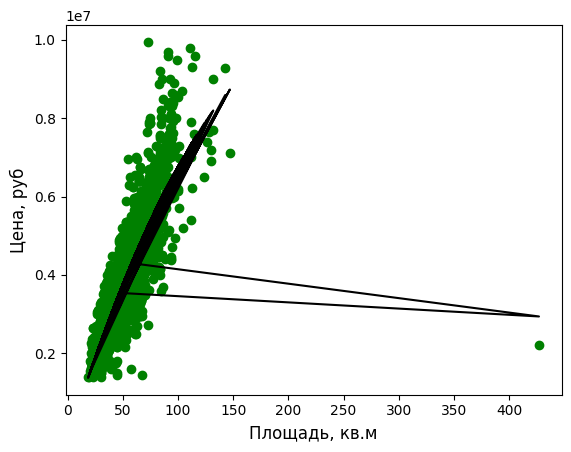

In [ ]:
X2 = X[feature_cols[0]].values[:, np.newaxis]
y2 = y.values

poly_features = poly.fit_transform(X2)

model2 = LinearRegression()
model2.fit(poly_features, y2)

plt.scatter(X2, y2, color='g')
plt.plot(X2, model2.predict(poly.fit_transform(X2)), color='k')
plt.ylabel('Цена, руб', size=12)
plt.xlabel('Площадь, кв.м', size=12)

Сравнение моделей

In [ ]:
results_df = pd.DataFrame(results).T
print(results_df.round(2))

                             MAE        RMSE    R2  Adj_R2  CV_R2
Linear Regression      523364.61  1330537.17  0.05    0.03   0.78
Decision Tree          432303.32   685048.32  0.75    0.74   0.75
Random Forest          367921.89   575809.19  0.82    0.82   0.85
Polynomial Regression  445092.11   621303.62  0.81    0.81   0.79


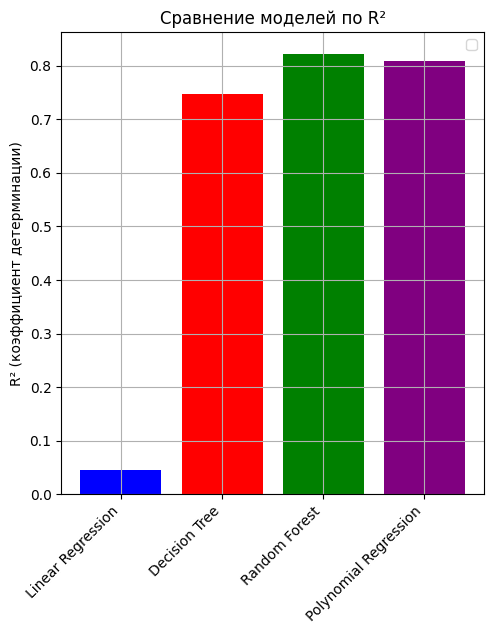

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
bars = plt.bar(results_df.index, results_df['R2'], color=['blue', 'red', 'green', 'purple'])
plt.ylabel('R² (коэффициент детерминации)')
plt.title('Сравнение моделей по R²')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True)

видно что лучшая модель это Random Forest

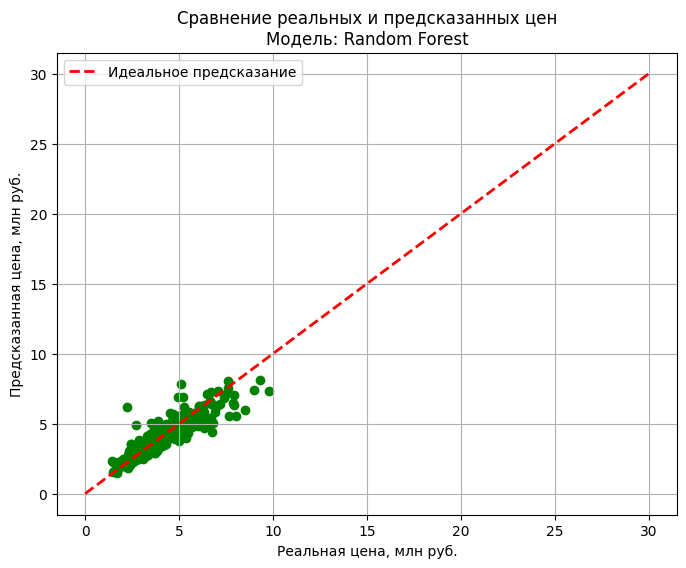

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test / 1_000_000, y_rf_pred / 1_000_000, color='green')
plt.plot([0, 30], [0, 30], 'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Реальная цена, млн руб.')
plt.ylabel('Предсказанная цена, млн руб.')
plt.title('Сравнение реальных и предсказанных цен\nМодель: Random Forest')
plt.legend()
plt.grid(True)

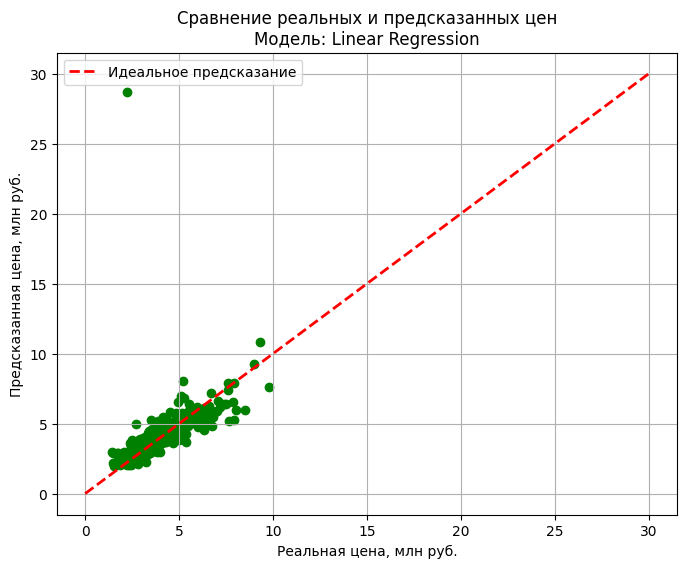

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test / 1_000_000, y_pr_LR / 1_000_000, color='green')
plt.plot([0, 30], [0, 30], 'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Реальная цена, млн руб.')
plt.ylabel('Предсказанная цена, млн руб.')
plt.title('Сравнение реальных и предсказанных цен\nМодель: Linear Regression')
plt.legend()
plt.grid(True)

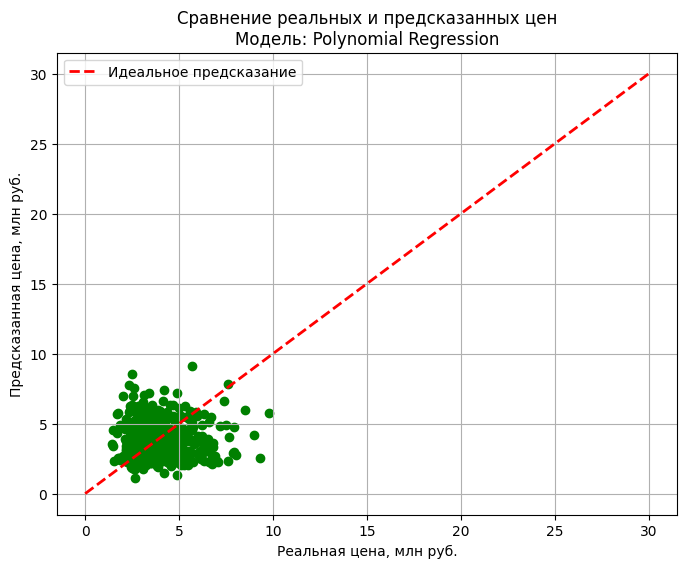

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test / 1_000_000, y_pr_PR / 1_000_000, color='green')
plt.plot([0, 30], [0, 30], 'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Реальная цена, млн руб.')
plt.ylabel('Предсказанная цена, млн руб.')
plt.title('Сравнение реальных и предсказанных цен\nМодель: Polynomial Regression')
plt.legend()
plt.grid(True)

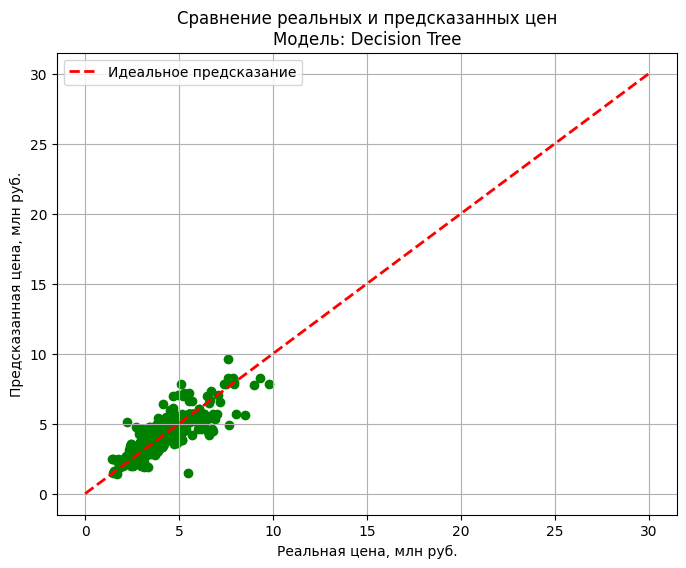

In [201]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test / 1_000_000, y_pred_DT / 1_000_000, color='green')
plt.plot([0, 30], [0, 30], 'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Реальная цена, млн руб.')
plt.ylabel('Предсказанная цена, млн руб.')
plt.title('Сравнение реальных и предсказанных цен\nМодель: Decision Tree')
plt.legend()
plt.grid(True)

Важность признаков

In [202]:
feature_importance = pd.DataFrame({'Признак': feature_cols,'Важность': modelRF.feature_importances_}).sort_values('Важность', ascending=False)
print(feature_importance.to_string(index=False))

      Признак  Важность
         area  0.802291
 kitchen_area  0.085684
       levels  0.056242
        level  0.023696
building_type  0.013694
        rooms  0.010364
  object_type  0.008029


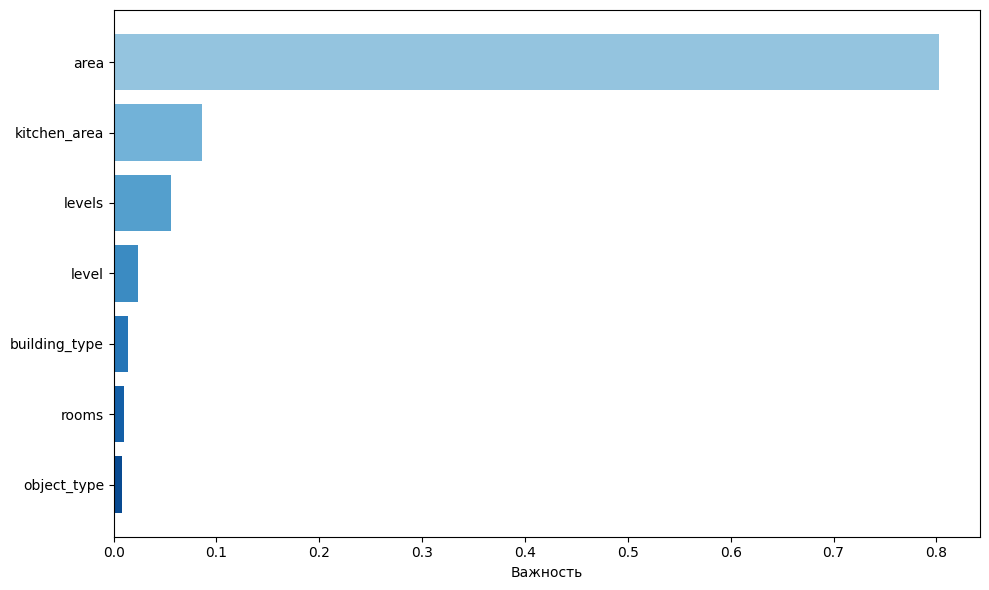

In [ ]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_importance)))
plt.barh(feature_importance['Признак'], feature_importance['Важность'], color=colors)
plt.xlabel('Важность')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()